# Bài tập Buổi 7 — Bài 1: Logistic Regression trên Titanic

**Sinh viên thực hiện:** Mai Gia Bảo - 24520163

---

## Bối cảnh
Dùng lại bộ **Titanic** ở buổi trước để dự đoán hành khách sống sót hay không, đây là bài toán **phân loại nhị phân**. File readem của thầy yêu cầu huấn luyện **Logistic Regression**, rồi so sánh với **Linear Regression**  để thấy vì sao Logistic hợp với bài toán phân loại hơn.

So sánh dựa trên: Accuracy, Precision, Recall, F1-score và Confusion Matrix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Đã import xong thư viện.")

Đã import xong thư viện.


## 1. Tải dữ liệu và tiền xử lý (dùng lại cách làm buổi trước)
Bỏ các cột rò rỉ nhãn và trùng lặp, chỉ giữ 8 cột gốc giống bài Titanic buổi trước.

In [2]:
df = sns.load_dataset("titanic")

# bỏ cột rò rỉ nhãn (alive) và cột trùng thông tin, chỉ giữ 8 cột gốc
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df = df.drop(columns=leaky, errors="ignore")

print("Các cột còn lại:", list(df.columns))
print("Kích thước:", df.shape)
df.head()

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Kích thước: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 2. Chia train/test và xây pipeline tiền xử lý (fit chỉ trên train)
Chia 80/20. Biến số điền median rồi scale giống trong slide mấy buổi trc, biến phân loại điền mode rồi one-hot, pclass giữ nguyên.

In [3]:
X = df.drop(columns="survived")
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocess = ColumnTransformer([
    ("num", pipe_num, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

# fit CHỈ trên train để không rò rỉ dữ liệu
X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

print("Train/Test sau tiền xử lý:", X_train_t.shape, X_test_t.shape)
print("Tỷ lệ sống train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train/Test sau tiền xử lý: (712, 10) (179, 10)
Tỷ lệ sống train: 0.383 | test: 0.385


## 3. Huấn luyện Logistic Regression

In [4]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_t, y_train)
y_pred_log = logreg.predict(X_test_t)

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("=== Logistic Regression ===")
print(f"Accuracy : {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall   : {rec_log:.4f}")
print(f"F1-score : {f1_log:.4f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred_log, target_names=["Không sống (0)", "Sống (1)"]))

=== Logistic Regression ===
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244

Báo cáo chi tiết:
                precision    recall  f1-score   support

Không sống (0)       0.81      0.89      0.85       110
      Sống (1)       0.79      0.67      0.72        69

      accuracy                           0.80       179
     macro avg       0.80      0.78      0.79       179
  weighted avg       0.80      0.80      0.80       179



**Nhận xét:** Logistic Regression đạt accuracy khoảng 0.80, Precision khoảng 0.79 tức là trong số người mô hình đoán là sống thì phần lớn đoán đúng, còn Recall khoảng 0.67 nghĩa là mô hình bắt được khoảng hai phần ba số người thực sự sống.

## 4. Dùng thử Linear Regression cho bài toán phân loại
Linear Regression cho ra số thực liên tục chứ không phải nhãn 0 hoặc 1, nên đặt ngưỡng 0.5, nếu dự đoán lớn hơn hoặc bằng 0.5 thì xem là sống (1), ngược lại là không sống (0).

In [5]:
linreg = LinearRegression()
linreg.fit(X_train_t, y_train)

y_score_lin = linreg.predict(X_test_t)          # số thực liên tục
y_pred_lin = (y_score_lin >= 0.5).astype(int)   # đổi về nhãn 0/1 bằng ngưỡng 0.5

acc_lin = accuracy_score(y_test, y_pred_lin)
prec_lin = precision_score(y_test, y_pred_lin)
rec_lin = recall_score(y_test, y_pred_lin)
f1_lin = f1_score(y_test, y_pred_lin)

print("=== Linear Regression (ngưỡng 0.5) ===")
print(f"Accuracy : {acc_lin:.4f}")
print(f"Precision: {prec_lin:.4f}")
print(f"Recall   : {rec_lin:.4f}")
print(f"F1-score : {f1_lin:.4f}")
print("\nMột vài giá trị dự đoán thô của Linear (chưa đặt ngưỡng):")
print(np.round(y_score_lin[:8], 3))
print("Nhỏ nhất:", round(y_score_lin.min(), 3), "| Lớn nhất:", round(y_score_lin.max(), 3))

=== Linear Regression (ngưỡng 0.5) ===
Accuracy : 0.8101
Precision: 0.7869
Recall   : 0.6957
F1-score : 0.7385

Một vài giá trị dự đoán thô của Linear (chưa đặt ngưỡng):
[ 0.049 -0.019  0.183 -0.054  0.664  0.509  0.719  0.348]
Nhỏ nhất: -0.197 | Lớn nhất: 1.072


**Nhận xét:** Linear Regression cho ra những giá trị nằm **ngoài khoảng [0, 1]** (nhỏ nhất khoảng -0.20, lớn nhất khoảng 1.07), nghĩa là các số này không phải xác suất hợp lệ, phải ép ngưỡng thủ công mới ra được nhãn. Mô hình vốn được thiết kế để dự đoán số liên tục chứ không phải phân loại. (cái linear regression này phải xài cho bài tập buổi 6 dự đoán giá nhà thì hợp hơn)

## 5. So sánh hai mô hình

Bảng so sánh:
           Logistic Regression  Linear Regression
Accuracy                0.8045             0.8101
Precision               0.7931             0.7869
Recall                  0.6667             0.6957
F1-score                0.7244             0.7385


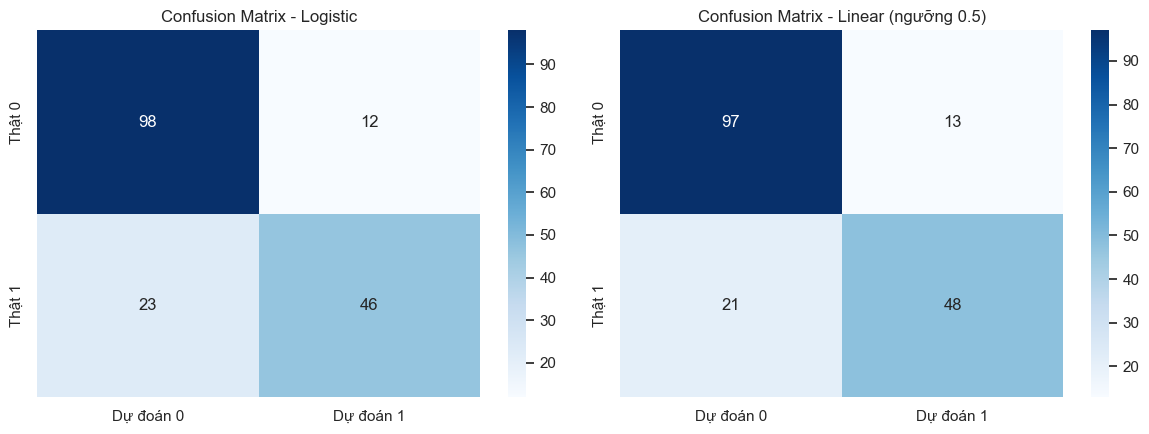

In [6]:
so_sanh = pd.DataFrame({
    "Logistic Regression": [acc_log, prec_log, rec_log, f1_log],
    "Linear Regression":   [acc_lin, prec_lin, rec_lin, f1_lin],
}, index=["Accuracy", "Precision", "Recall", "F1-score"]).round(4)
print("Bảng so sánh:")
print(so_sanh)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (ten, y_pred) in zip(axes, [("Logistic", y_pred_log), ("Linear (ngưỡng 0.5)", y_pred_lin)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Dự đoán 0", "Dự đoán 1"],
                yticklabels=["Thật 0", "Thật 1"])
    ax.set_title(f"Confusion Matrix - {ten}")
plt.tight_layout()
plt.show()

**Nhận xét tổng hợp:** Trên tập test này, hai mô hình cho kết quả khá sát nhau, thậm chí Linear Regression nhỉnh hơn một chút về accuracy (khoảng 0.810 so với 0.805). Tuy nhiên **Logistic Regression vẫn là lựa chọn phù hợp hơn** cho bài toán phân loại, vì mấy lý do sau. 
- Thứ nhất, Logistic cho ra xác suất nằm trong khoảng [0, 1] nên diễn giải được và không cần ép ngưỡng thủ công, còn Linear cho ra giá trị âm hoặc lớn hơn 1 không có ý nghĩa xác suất. 

- Thứ hai, Logistic tối ưu theo hàm mất mát phân loại (log-loss) nên hành xử ổn định hơn khi dữ liệu khó, còn Linear tối ưu theo sai số bình phương vốn dành cho hồi quy. Vì vậy với bài toán phân loại hành khách sống sót, chọn Logistic Regression còn mấy bài làm dự đoán giá nhà các kiểu giống bài tập buổi 6 thì sài Linear.